In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
#read in all the words
words=open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
#build the vocabulary of characters and mapping to/from integers
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
#builds the dataset

block_size = 3 #context langth: how many characters so we take to predict the next one?
X, Y = [], []

for w in words:


    context=[0]*block_size
    for ch in w + '.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        context=context[1:] +[ix] #crop and append


X=torch.tensor(X)
Y=torch.tensor(Y)

In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [10]:
#builds the dataset
def build_dataset(words):
    block_size = 3 #context langth: how many characters so we take to predict the next one?
    X, Y = [], []
    
    for w in words:
        
        context=[0]*block_size
        for ch in w + '.':
            ix=stoi[ch]
            X.append(context)
            Y.append(ix)
            context=context[1:] +[ix] #crop and append
    
    X=torch.tensor(X)
    Y=torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr =build_dataset(words[:n1])
Xdev, Ydev =build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [11]:
len(words)

32033

In [12]:
n1

25626

In [13]:
n2

28829

In [14]:
n2-n1

3203

In [15]:
len(words) - n2

3204

In [16]:
C=torch.randn((27,2))

In [17]:
emb=C[X]
emb.shape

torch.Size([228146, 3, 2])

In [18]:
W1=torch.randn((6, 100))
b1=torch.randn((100))

In [19]:
h=emb.view(-1, 6) @ W1+b1

In [20]:
h

tensor([[-0.0997,  0.2827, -1.3012,  ..., -0.6808,  0.7093,  1.0326],
        [-0.6902, -0.0977, -4.9318,  ..., -8.8516,  0.9258,  3.8794],
        [-3.2295,  0.9273, -1.4288,  ..., -5.0739, -1.1258,  6.1135],
        ...,
        [ 3.3381, -1.1119,  4.5255,  ...,  0.9973, -3.1907,  0.7884],
        [ 2.4736,  2.2475, -1.3748,  ...,  1.8646,  0.8839, -1.2085],
        [-1.5906, -2.9449, -1.9477,  ..., -7.0037, -1.6415,  5.9570]])

In [21]:
h=torch.tanh(emb.view(-1, 6) @ W1+b1)

In [22]:
h

tensor([[-0.0994,  0.2754, -0.8620,  ..., -0.5920,  0.6102,  0.7749],
        [-0.5981, -0.0974, -0.9999,  ..., -1.0000,  0.7286,  0.9991],
        [-0.9969,  0.7293, -0.8914,  ..., -0.9999, -0.8096,  1.0000],
        ...,
        [ 0.9975, -0.8047,  0.9998,  ...,  0.7605, -0.9966,  0.6575],
        [ 0.9859,  0.9779, -0.8798,  ...,  0.9531,  0.7084, -0.8362],
        [-0.9202, -0.9945, -0.9601,  ..., -1.0000, -0.9277,  1.0000]])

In [23]:
h.shape

torch.Size([228146, 100])

In [24]:
W2=torch.randn((100,27))
b2=torch.rand(27)

In [25]:
logits=h @ W2 + b2

In [26]:
logits.shape

torch.Size([228146, 27])

In [27]:
counts=logits.exp()

In [28]:
prob=counts / counts.sum(1, keepdims=True)

In [29]:
prob.shape

torch.Size([228146, 27])

In [30]:
loss=-prob[torch.arange(32), Y].log().mean()
loss

IndexError: shape mismatch: indexing tensors could not be broadcast together with shapes [32], [228146]

In [31]:
Xtr.shape, Ytr.shape #dataset

(torch.Size([182625, 3]), torch.Size([182625]))

In [32]:
g=torch.Generator().manual_seed(2147483647) # fpr reproducibility
C=torch.randn((27, 10), generator=g)
W1=torch.randn((30, 200), generator=g)
b1=torch.randn(200, generator=g)
W2=torch.randn((200,27), generator=g)
b2=torch.randn(27, generator=g)
parameters=[C, W1, b1, W2, b2]

In [33]:
sum(p.nelement() for p in parameters) #number of parameter in total

11897

In [34]:
for p in parameters:
    p.requires_grad=True

In [35]:
lre=torch.linspace(-3, 0, 1000)
lrs=10**lre

In [36]:
lri=[]
lossi=[]
stepi=[]

In [41]:

for i in  range(200000):
    # minibach constructa
    ix=torch.randint(0, Xtr.shape[0], (32,))
    
    #forward pass
    emb=C[Xtr[ix]] #(32, 3, 2)
    h=torch.tanh(emb.view(-1, 30) @ W1+b1) #(32, 100)
    logits=h @ W2+b2 #(32, 27)
    #counts=logits.exp()
    #prob=counts / counts.sum(1, keepdims=True)
    #loss=-prob[torch.arange(32), Y].log().mean()
    loss=F.cross_entropy(logits,Ytr[ix])


    
    #backward pass
    for p in parameters:
        p.grad=None
    loss.backward()
    
    #update
    #lr = lrs[i]
    lr=0.005
    for p in parameters:
        p.data += -lr *p.grad

    #track stats
    #lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

print(loss.item())

1.8079533576965332


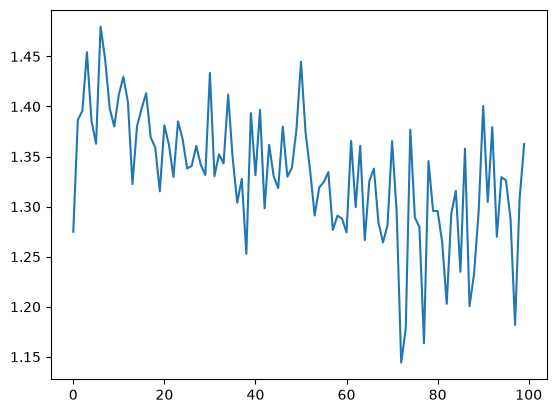

In [38]:
plt.plot(stepi, lossi)

In [39]:
emb=C[Xdev] #(32, 3, 2)
h=torch.tanh(emb.view(-1, 30) @ W1+b1) #(32, 100)
logits=h @ W2+b2 #(32, 27)
loss=F.cross_entropy(logits,Ydev)
loss

tensor(19.3669, grad_fn=<NllLossBackward0>)

In [40]:
emb=C[Xtr] #(32, 3, 2)
h=torch.tanh(emb.view(-1, 30) @ W1+b1) #(32, 100)
logits=h @ W2+b2 #(32, 27)
loss=F.cross_entropy(logits,Ytr)
loss

tensor(19.3493, grad_fn=<NllLossBackward0>)

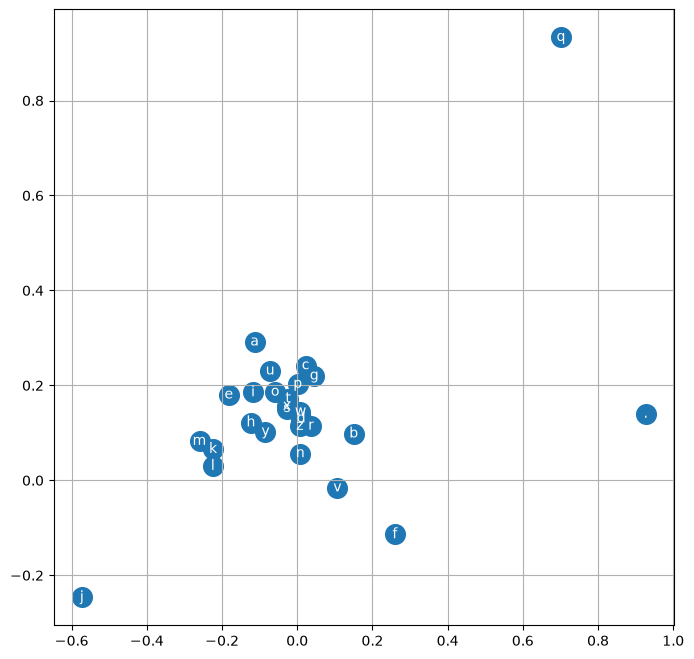

In [42]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va= "center", color="white")
plt.grid('minor')

In [39]:
#traing split, dev/validation slit, test split
#80%, 10%, 10%,    why not just not change the weight and bise for test split???
